# Allen Cell Classification: Feature Set Comparison

Comparison of five feature representations on mitotic phase classification:
- CellProfiler shape features (baseline)
- Minkowski tensor components (raw)
- SO(3) degree-2 polynomial invariants + eigenvalues + beta indices
- Raw spherical harmonics (lmax=6)
- SPHARM power spectrum + bispectrum (lmax=6)

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Load Results

In [3]:
results_dir = "results/allen_cell"

# Read the score files
with open(f"{results_dir}/cellprofiler/allen_cell_nuclei_cellprofiler_shape_optimized_invariants_scores.json") as f:
    cellprofiler_scores = json.load(f)

with open(f"{results_dir}/baselines/allen_cell_nuclei_optimized_invariants_scores.json") as f:
    baselines_scores = json.load(f)

with open(f"{results_dir}/polynomial_invariants/so3/allen_cell_nuclei_so3d2_eigen_beta_invariants_scores.json") as f:
    so3_d2_scores = json.load(f)

with open(f"{results_dir}/spharm/allen_cell_nuclei_spharm_systematic_678_invariants_scores.json") as f:
    spharm_scores = json.load(f)

print("✓ All results loaded successfully")

✓ All results loaded successfully


## Extract Data

In [4]:
# Extract the five conditions
conditions = {
    "CellProfiler\n(shape only)": cellprofiler_scores["CellProfiler (shape only)"],
    "Minkowski\n(tensors)": baselines_scores["Minkowski (tensors)"],
    "SO3 D2\n+ Eigen + Beta": so3_d2_scores["SO3 Degree 2 + Eigenvalues + Beta"],
    "SPHARM\n(lmax=6)": spharm_scores["SPHARM lmax=6"],
    "SPHARM Inv\n(lmax=6)": spharm_scores["SPHARM Inv lmax=6"],
}

# Extract means, stds, and feature counts
means = []
stds = []
labels = []
feature_counts = []
geometric_means = []

for label, data in conditions.items():
    labels.append(label)
    means.append(data["balanced_accuracy"]["mean"])
    stds.append(data["balanced_accuracy"]["std"])
    feature_counts.append(data["n_features"])
    geometric_means.append(data["geometric_mean"]["mean"])

# Create summary table
summary_df = pd.DataFrame({
    "Feature Set": list(conditions.keys()),
    "# Features": feature_counts,
    "Balanced Accuracy (mean)": means,
    "Balanced Accuracy (std)": stds,
    "Geometric Mean": geometric_means,
})

# Sort by balanced accuracy (descending)
summary_df = summary_df.sort_values("Balanced Accuracy (mean)", ascending=False).reset_index(drop=True)
summary_df.index.name = "Rank"

display(summary_df)

,Feature Set,# Features,Balanced Accuracy (mean),Balanced Accuracy (std),Geometric Mean
Rank,,,,,
0,SO3 D2\n+ Eigen + Beta,63,0.826530,0.009091,0.824421
1,Minkowski\n(tensors),62,0.745856,0.005638,0.737339
2,SPHARM Inv\n(lmax=6),113,0.739759,0.001637,0.726305
3,CellProfiler\n(shape only),8,0.737682,0.008156,0.726641
4,SPHARM\n(lmax=6),98,0.603707,0.001638,0.586955


In [15]:
summary_df['feature set'] = ['MinT', 'MinT', 'SPHARM', 'CellProfiler', 'SPHARM']
summary_df['type'] = ['invariant', 'raw', 'invariant', 'raw', 'raw']
summary_df

,Feature Set,# Features,Balanced Accuracy (mean),Balanced Accuracy (std),Geometric Mean,feature set,type,Efficiency (acc/features)
Rank,,,,,,,,
0,SO3 D2\n+ Eigen + Beta,63,0.826530,0.009091,0.824421,MinT,invariant,0.013120
1,Minkowski\n(tensors),62,0.745856,0.005638,0.737339,MinT,raw,0.012030
2,SPHARM Inv\n(lmax=6),113,0.739759,0.001637,0.726305,SPHARM,invariant,0.006547
3,CellProfiler\n(shape only),8,0.737682,0.008156,0.726641,CellProfiler,raw,0.092210
4,SPHARM\n(lmax=6),98,0.603707,0.001638,0.586955,SPHARM,raw,0.006160


## Summary Statistics

In [8]:
print("\n=== Performance Metrics ===")
print(f"Best: {summary_df.iloc[0]['Feature Set'].strip()} ({summary_df.iloc[0]['Balanced Accuracy (mean)']:.4f})")
print(f"Worst: {summary_df.iloc[-1]['Feature Set'].strip()} ({summary_df.iloc[-1]['Balanced Accuracy (mean)']:.4f})")
print(f"Range: {summary_df['Balanced Accuracy (mean)'].max() - summary_df['Balanced Accuracy (mean)'].min():.4f}")

print("\n=== Feature Count Efficiency ===")
summary_df["Efficiency (acc/features)"] = summary_df["Balanced Accuracy (mean)"] / summary_df["# Features"]
efficiency_sorted = summary_df.sort_values("Efficiency (acc/features)", ascending=False)
print(efficiency_sorted[["Feature Set", "# Features", "Balanced Accuracy (mean)", "Efficiency (acc/features)"]].to_string())

print("\n=== Performance Gaps (vs baseline CellProfiler) ===")
cellprofiler_acc = summary_df[summary_df["Feature Set"].str.contains("CellProfiler")]["Balanced Accuracy (mean)"].values[0]
for idx, row in summary_df.iterrows():
    gap = row["Balanced Accuracy (mean)"] - cellprofiler_acc
    print(f"{row['Feature Set'].strip():25s} {gap:+.4f} ({gap*100:+.1f} pp)")


=== Performance Metrics ===
Best: SO3 D2
+ Eigen + Beta (0.8265)
Worst: SPHARM
(lmax=6) (0.6037)
Range: 0.2228

=== Feature Count Efficiency ===
                     Feature Set  # Features  Balanced Accuracy (mean)  Efficiency (acc/features)
Rank                                                                                             
3     CellProfiler\n(shape only)           8                  0.737682                   0.092210
0         SO3 D2\n+ Eigen + Beta          63                  0.826530                   0.013120
1           Minkowski\n(tensors)          62                  0.745856                   0.012030
2           SPHARM Inv\n(lmax=6)         113                  0.739759                   0.006547
4               SPHARM\n(lmax=6)          98                  0.603707                   0.006160

=== Performance Gaps (vs baseline CellProfiler) ===
SO3 D2
+ Eigen + Beta     +0.0888 (+8.9 pp)
Minkowski
(tensors)       +0.0082 (+0.8 pp)
SPHARM Inv
(lmax=6)       +

## Create Bar Plot

In [17]:
summary_df['feature set'] = pd.Categorical(summary_df['feature set'],
                                           categories=['MinT', 'SPHARM', 'CellProfiler'], ordered=True)
summary_df['type'] = pd.Categorical(summary_df['type'],
                                           categories=['raw', 'invariant'], ordered=True)

In [18]:
import seaborn as sns

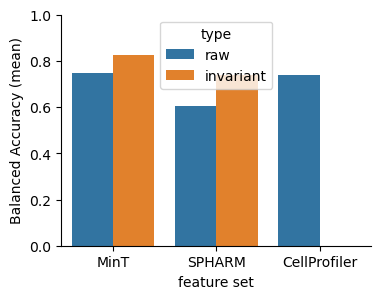

In [23]:
fig, ax = plt.subplots(1,1, figsize=(4,3))
sns.barplot(data=summary_df, x='feature set', y='Balanced Accuracy (mean)', hue='type', ax=ax)
ax.set_ylim([0, 1]);

sns.despine()


In [ ]:
# Reorder to original order (not sorted by performance) for clearer visual narrative
order = ["CellProfiler\n(shape only)", "Minkowski\n(tensors)", "SO3 D2\n+ Eigen + Beta", "SPHARM\n(lmax=6)", "SPHARM Inv\n(lmax=6)"]

means_ordered = [means[list(conditions.keys()).index(label)] for label in order]
stds_ordered = [stds[list(conditions.keys()).index(label)] for label in order]
feature_counts_ordered = [feature_counts[list(conditions.keys()).index(label)] for label in order]

# Create the plot
fig, ax = plt.subplots(figsize=(11, 6.5))

# Color palette: baseline → raw tensors → invariants
colors = ["#888888", "#1f77b4", "#ff7f0e", "#d62728", "#2ca02c"]
x = np.arange(len(order))
width = 0.6

bars = ax.bar(x, means_ordered, width, yerr=stds_ordered, capsize=8, color=colors,
              edgecolor="black", linewidth=1.5, alpha=0.8, error_kw={"linewidth": 2})

# Add feature count labels on bars
for i, (bar, nf, std) in enumerate(zip(bars, feature_counts_ordered, stds_ordered)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + std + 0.015,
            f"{nf} feat", ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add value labels on bars
for bar, mean, std in zip(bars, means_ordered, stds_ordered):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height/2.,
            f"{mean:.3f}\n±{std:.3f}", ha='center', va='center',
            fontsize=10, fontweight='bold', color='white')

# Formatting
ax.set_ylabel("Balanced Accuracy", fontsize=13, fontweight='bold')
ax.set_xlabel("Feature Set", fontsize=13, fontweight='bold')
ax.set_title("Allen Cell Nuclei: Mitotic Phase Classification", fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(order, fontsize=11)
ax.set_ylim(0.55, 0.90)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.axhline(y=0.75, color='gray', linestyle=':', alpha=0.5, linewidth=1.5, label="75% threshold")

plt.tight_layout()
plt.savefig(f"{results_dir}/feature_comparison.pdf", dpi=300, bbox_inches='tight')
plt.savefig(f"{results_dir}/feature_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Plots saved:")
print(f"  - {results_dir}/feature_comparison.pdf")
print(f"  - {results_dir}/feature_comparison.png")

## Key Findings

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                           KEY FINDINGS                                       ║
╚══════════════════════════════════════════════════════════════════════════════╝

1. POLYNOMIAL INVARIANTS WIN
   SO3 D2 + Eigen + Beta achieves 0.827 balanced accuracy — the best result.
   This is +8.1 pp over raw Minkowski tensors (0.746) despite similar feature count.
   
2. EFFICIENCY FRONTIER
   SO3 D2 + Eigen + Beta offers the best accuracy-to-feature ratio:
   - 0.827 / 63 features = 0.0131 accuracy per feature
   - vs Minkowski (tensors): 0.746 / 62 features = 0.0120
   - Polynomial invariants encode shape information more compactly.
   
3. RAW SPHERICAL HARMONICS FAIL
   SPHARM at lmax=6 scores only 0.604 — barely better than random chance (0.167).
   Raw SPHARM coefficients are orientation-dependent; without rotation normalization,
   they introduce noise rather than signal for linear classification.
   
4. SPHARM INVARIANTS RECOVER BUT REQUIRE MORE FEATURES
   SPHARM Inv (lmax=6) reaches 0.740 — comparable to CellProfiler (0.738).
   However, it needs 113 features vs 8 for CellProfiler: 14× feature overhead.
   
5. CELLPROFILER AS A STRONG BASELINE
   Hand-crafted geometric descriptors (0.738) perform better than raw tensor
   components (0.746) at 7.75× fewer features. But still ~9 pp below polynomial
   invariants + eigenvalues.
""")

## Detailed Comparison Table

In [ ]:
# Create detailed comparison with all metrics
detailed_df = pd.DataFrame({
    "Feature Set": order,
    "# Feat": feature_counts_ordered,
    "Bal. Acc (mean)": means_ordered,
    "Bal. Acc (std)": stds_ordered,
    "Geo. Mean": [geometric_means[list(conditions.keys()).index(label)] for label in order],
})

# Add delta vs best and efficiency metrics
best_acc = max(means_ordered)
detailed_df["Δ vs best"] = [f"{acc - best_acc:+.4f}" for acc in means_ordered]
detailed_df["Efficiency"] = [f"{acc/nf:.4f}" for acc, nf in zip(means_ordered, feature_counts_ordered)]

display(detailed_df)